In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [2]:
df_temp = pd.read_csv("../../data/csv/air_pollution.csv")

In [3]:
list_IndicatorCode = ["AIR_4","AIR_5","AIR_6","AIR_7","AIR_8","AIR_9","SDGPM25"]
df = df_temp[df_temp["IndicatorCode"].isin(list_IndicatorCode)].copy()

In [4]:
df.reset_index(drop=True, inplace=True)
df.columns

Index(['Unnamed: 0', 'ParentLocationCode', 'SpatialDim', 'Value',
       'NumericValue', 'TimeDimensionBegin', 'TimeDimensionEnd',
       'TimeDimensionValue', 'TimeDimType', 'TimeDim', 'IndicatorCode',
       'Date'],
      dtype='object')

In [5]:
df["ParentLocationCode"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 65113 entries, 0 to 65112
Series name: ParentLocationCode
Non-Null Count  Dtype 
--------------  ----- 
50625 non-null  object
dtypes: object(1)
memory usage: 508.8+ KB


'''
 0   ParentLocationCode  :object  :Mã khu vực
 1   SpatialDim          :object  :Không gian địa lý (mã quốc gia hoặc vùng)
 2   Dim1                :object  :Chiều để phân loại phụ 
 3   Value               :object  :Giá trị gốc của WHO (để kiểm tra dữ liệu thô)
 4   NumericValue        :float64 :Phiên bản số hóa của Value (tính toán, thống kê, vẽ)
 5   Date                :object  :Năm hoặc khoảng thời gian
 6   IndicatorCode       :object  :Mã chỉ số y tế
'''

In [6]:
df.describe()

,Unnamed: 0,NumericValue,TimeDimensionValue,TimeDim
count,65113.000000,6.511300e+04,65113.000000,65113.000000
mean,373818.649671,2.027952e+05,2015.893477,2015.893477
std,73114.290143,2.169948e+06,3.166120,3.166120
min,150301.000000,0.000000e+00,2010.000000,2010.000000
25%,362396.000000,1.326748e+01,2013.000000,2013.000000
50%,378674.000000,2.349390e+02,2017.000000,2017.000000
75%,397679.000000,1.198851e+04,2019.000000,2019.000000
max,491075.000000,1.138005e+08,2019.000000,2019.000000


In [7]:
df.describe(include='object')

,ParentLocationCode,SpatialDim,Value,TimeDimensionBegin,TimeDimensionEnd,TimeDimType,IndicatorCode,Date
count,50625,65113,65113,65113,65113,65113,65113,65113
unique,6,240,57512,10,10,1,7,600
top,EUR,WPR,0 [0-0],2019-01-01T00:00:00+01:00,2019-12-31T00:00:00+01:00,YEAR,AIR_7,2024-10-03T16:01:00.947+02:00
freq,13850,656,645,24658,24658,65113,34200,34200


In [8]:
df.isnull().sum()

Unnamed: 0                0
ParentLocationCode    14488
SpatialDim                0
Value                     0
NumericValue              0
TimeDimensionBegin        0
TimeDimensionEnd          0
TimeDimensionValue        0
TimeDimType               0
TimeDim                   0
IndicatorCode             0
Date                      0
dtype: int64

In [9]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [10]:
df.dropna(subset = ["ParentLocationCode"],axis = 0, inplace = True )
df["ParentLocationCode"].isnull().value_counts()

ParentLocationCode
False    50625
Name: count, dtype: int64

In [11]:
df["SpatialDim"].isnull().value_counts()
df["Value"].isnull().value_counts()

Value
False    50625
Name: count, dtype: int64

In [12]:
# df.drop(columns= ["Value"], axis=1 , errors= "ignore", inplace=True)
df.columns

Index(['ParentLocationCode', 'SpatialDim', 'Value', 'NumericValue',
       'TimeDimensionBegin', 'TimeDimensionEnd', 'TimeDimensionValue',
       'TimeDimType', 'TimeDim', 'IndicatorCode', 'Date'],
      dtype='object')

In [13]:
df["NumericValue"].isnull().value_counts()

NumericValue
False    50625
Name: count, dtype: int64

In [14]:
# df.drop(columns= ["TimeDimType"], axis=1 , errors= "ignore", inplace=True)

df["TimeDimensionBegin"] = pd.to_datetime(df["TimeDimensionBegin"], format="ISO8601")
print(df["TimeDimensionBegin"].isnull().value_counts())

df["TimeDimensionEnd"] = pd.to_datetime(df["TimeDimensionEnd"], format="ISO8601")
print(df["TimeDimensionEnd"].isnull().value_counts())

df["TimeDimensionValue"] = pd.to_datetime(df["TimeDimensionValue"], format="ISO8601")
print(df["TimeDimensionValue"].isnull().value_counts())

# df.drop(columns= ["TimeDimensionBegin"], axis=1 , errors= "ignore", inplace=True)
# df.drop(columns= ["TimeDimensionEnd"], axis=1 , errors= "ignore", inplace=True)
# df.drop(columns= ["TimeDimensionValue"], axis=1 , errors= "ignore", inplace=True)

print(df.columns)

TimeDimensionBegin
False    50625
Name: count, dtype: int64
TimeDimensionEnd
False    50625
Name: count, dtype: int64
TimeDimensionValue
False    50625
Name: count, dtype: int64
Index(['ParentLocationCode', 'SpatialDim', 'Value', 'NumericValue',
       'TimeDimensionBegin', 'TimeDimensionEnd', 'TimeDimensionValue',
       'TimeDimType', 'TimeDim', 'IndicatorCode', 'Date'],
      dtype='object')


In [15]:
print(df["IndicatorCode"].unique())

df["TimeDim"] = pd.to_datetime(df["TimeDim"], format="ISO8601")

df["TimeDim"] = df["TimeDim"].dt.year
df["TimeDim"].unique()
df["TimeDimensionValue"].unique()

['AIR_4' 'AIR_5' 'AIR_6' 'AIR_7' 'AIR_8' 'AIR_9' 'SDGPM25']


<DatetimeArray>
['2019-01-01 00:00:00', '2016-01-01 00:00:00', '2017-01-01 00:00:00',
 '2013-01-01 00:00:00', '2011-01-01 00:00:00', '2012-01-01 00:00:00',
 '2010-01-01 00:00:00', '2018-01-01 00:00:00', '2014-01-01 00:00:00',
 '2015-01-01 00:00:00']
Length: 10, dtype: datetime64[ns]

In [ ]:
# df.to_csv("csv_air.csv", index=False)

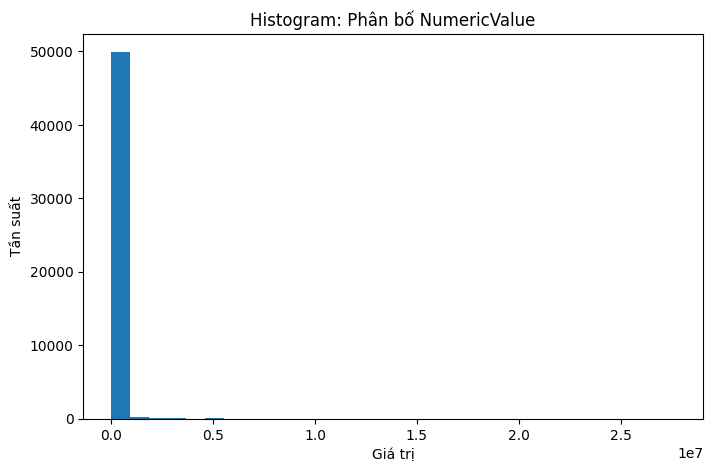

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df["NumericValue"].dropna(), bins=30)
plt.title("Histogram: Phân bố NumericValue")
plt.xlabel("Giá trị")
plt.ylabel("Tần suất")
plt.show()

Text(0.5, 1.0, 'Boxplot: Phân bố NumericValue / IndicatorCode')

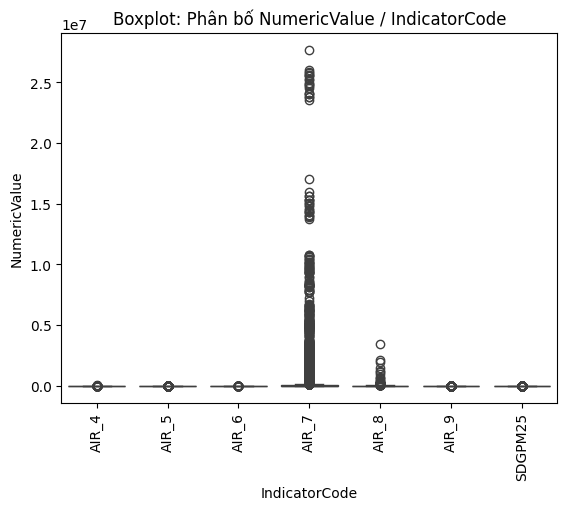

In [17]:
sns.boxplot(df, x = "IndicatorCode", y = "NumericValue")
plt.xticks(rotation=90);
plt.title("Boxplot: Phân bố NumericValue / IndicatorCode")

Text(0.5, 1.0, 'Boxplot: Phân bố NumericValue / IndicatorCode (Chuẩn hóa Log)')

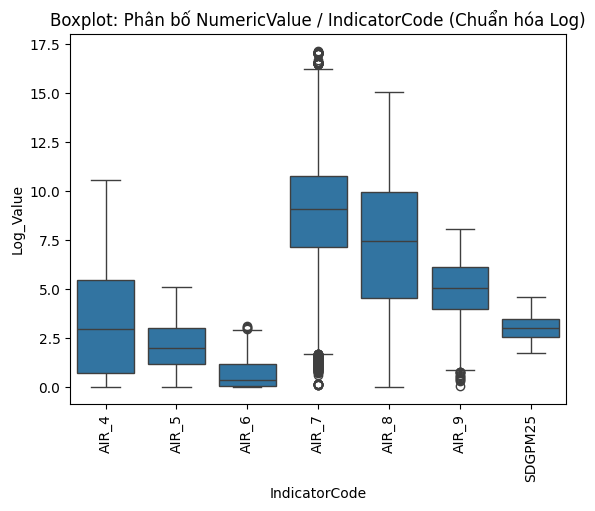

In [18]:
df['Log_Value'] = np.log1p(df['NumericValue'])
sns.boxplot(data=df, x="IndicatorCode", y="Log_Value")
plt.xticks(rotation=90);
plt.title("Boxplot: Phân bố NumericValue / IndicatorCode (Chuẩn hóa Log)")

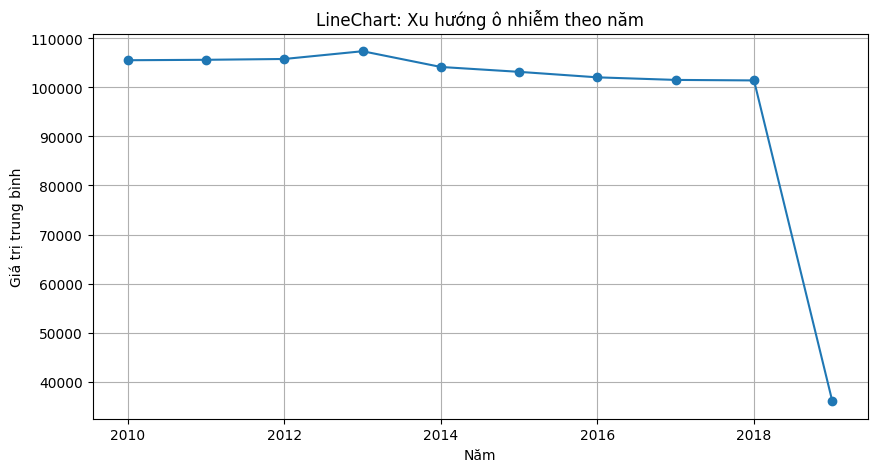

In [19]:
df_year = (
    df.groupby("TimeDim")["NumericValue"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(df_year["TimeDim"], df_year["NumericValue"], marker="o")
plt.title("LineChart: Xu hướng ô nhiễm theo năm")
plt.xlabel("Năm")
plt.ylabel("Giá trị trung bình")
plt.grid(True)
plt.show()


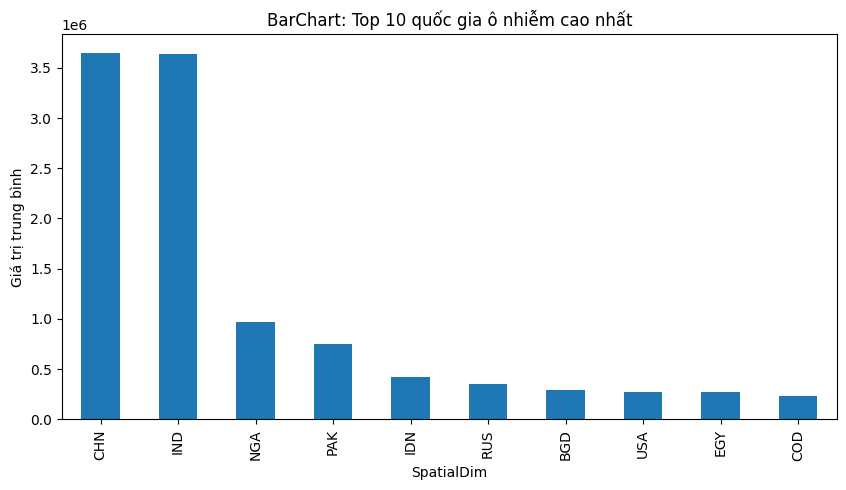

In [20]:
df_country = (
    df.groupby("SpatialDim")["NumericValue"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

df_country.plot(kind="bar", figsize=(10,5))
plt.title("BarChart: Top 10 quốc gia ô nhiễm cao nhất")
plt.ylabel("Giá trị trung bình")
plt.show()


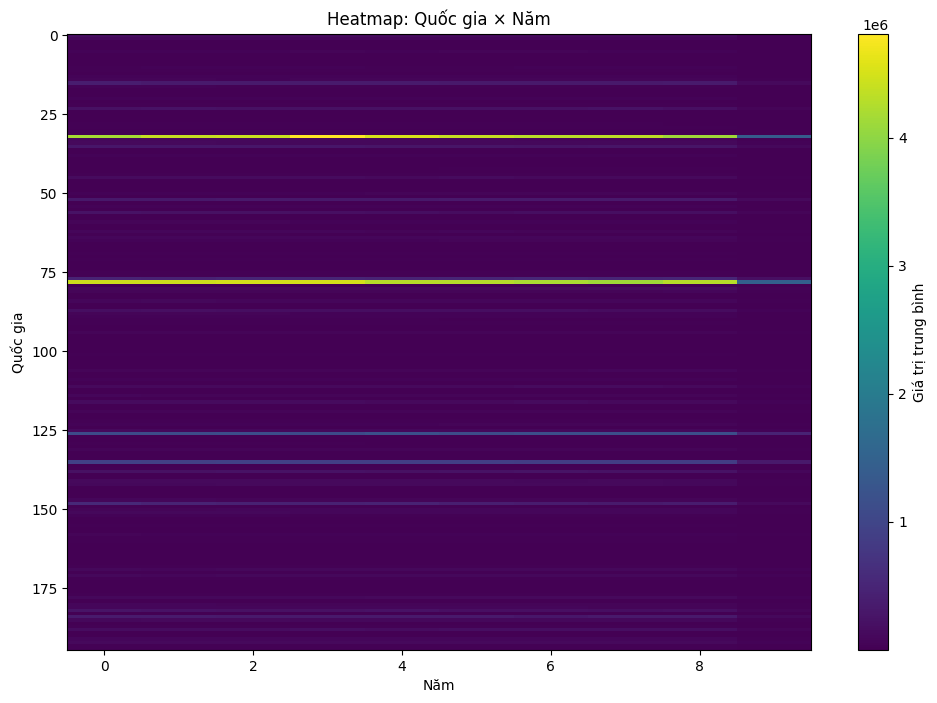

In [21]:
pivot = df.pivot_table(
    index="SpatialDim",
    columns="TimeDim",
    values="NumericValue",
    aggfunc="mean"
)

plt.figure(figsize=(12,8))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Giá trị trung bình")
plt.title("Heatmap: Quốc gia × Năm")
plt.xlabel("Năm")
plt.ylabel("Quốc gia")
plt.show()


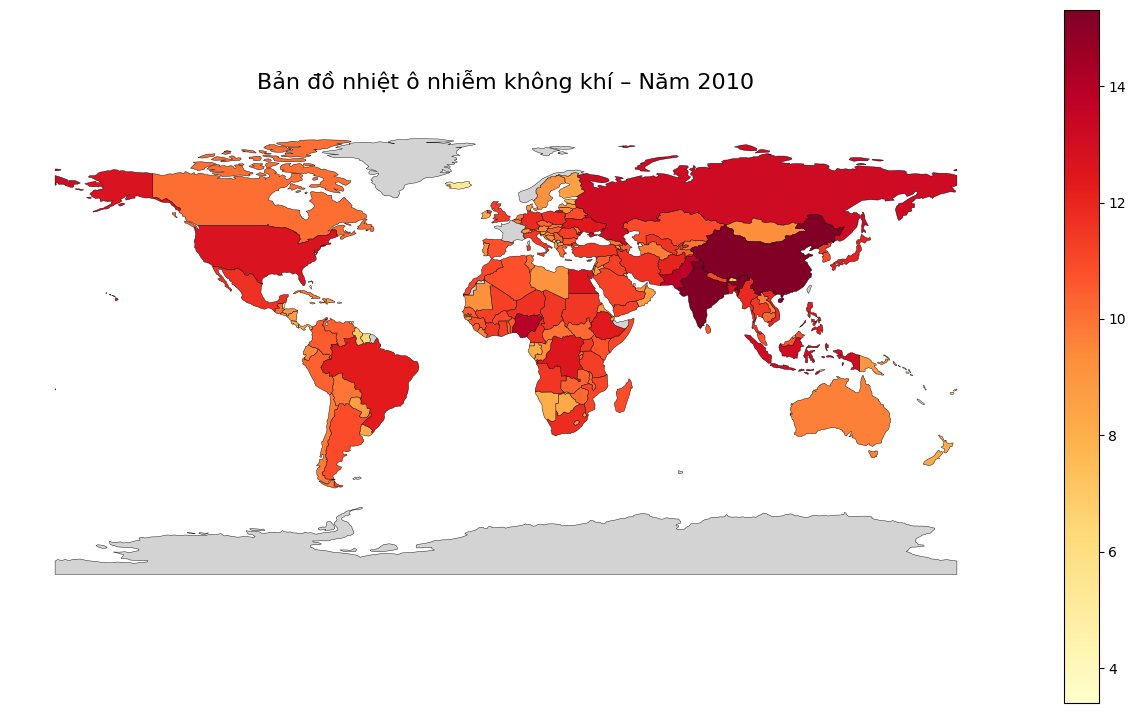

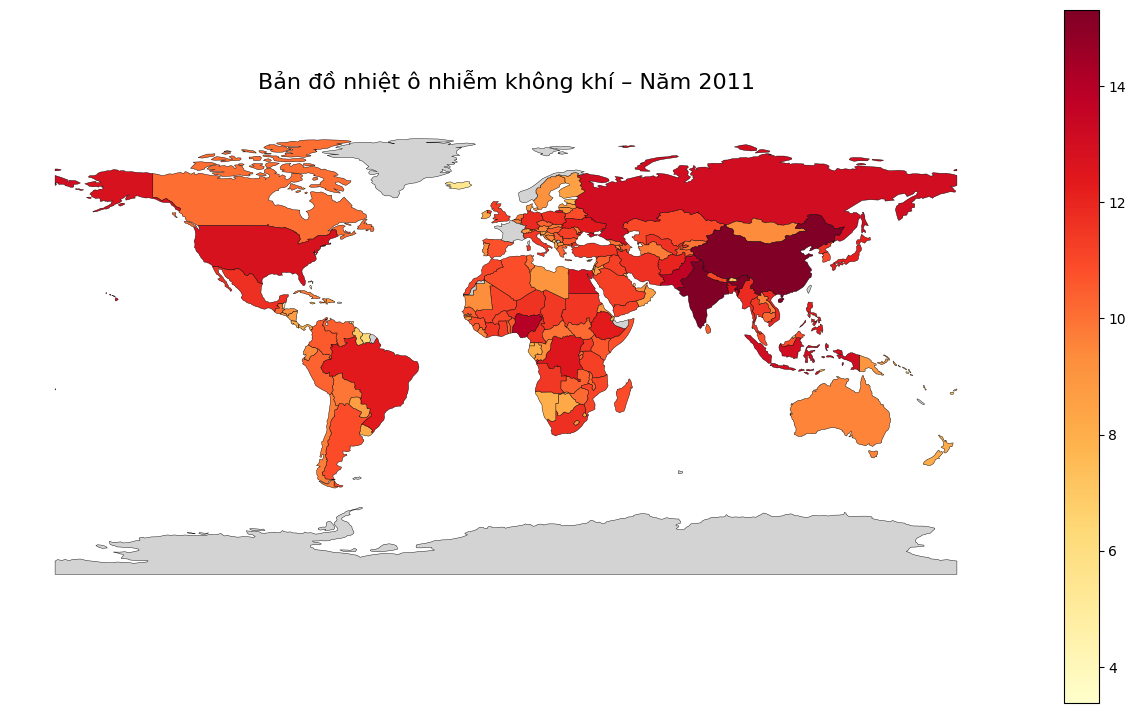

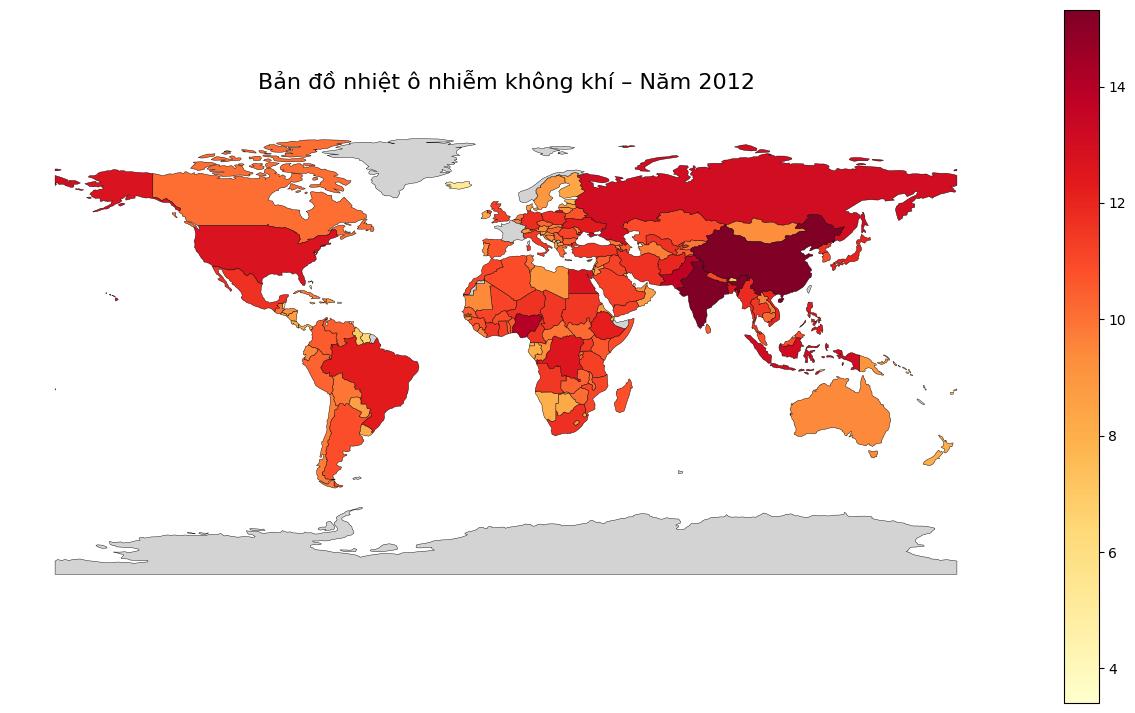

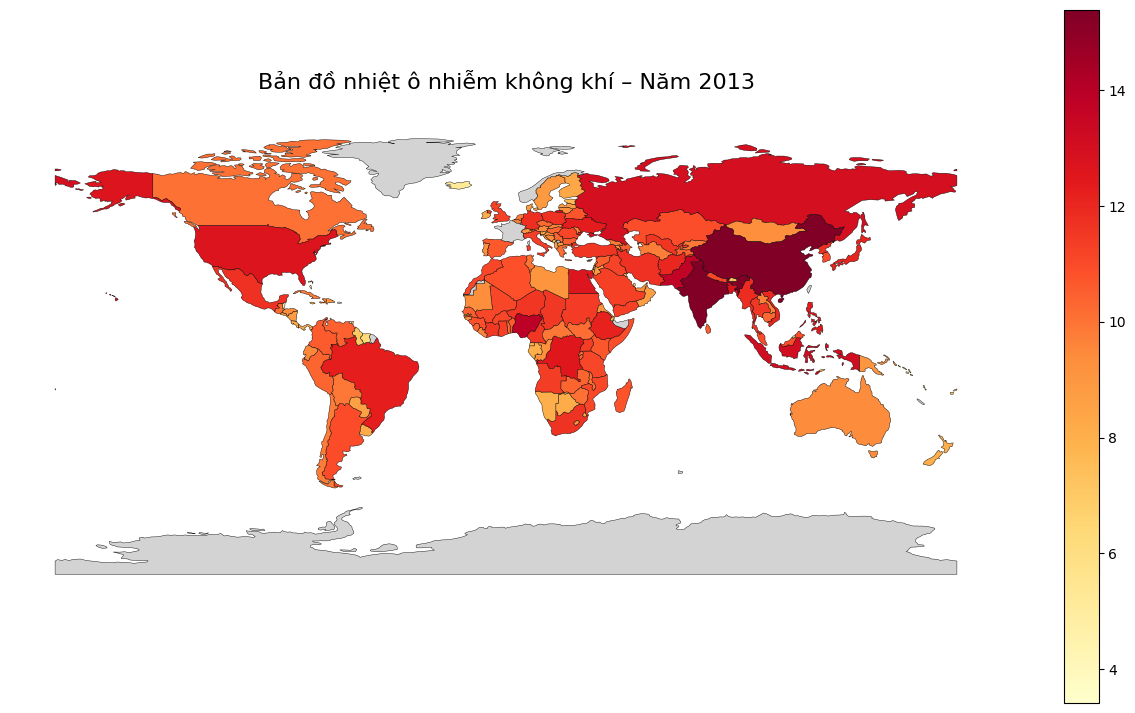

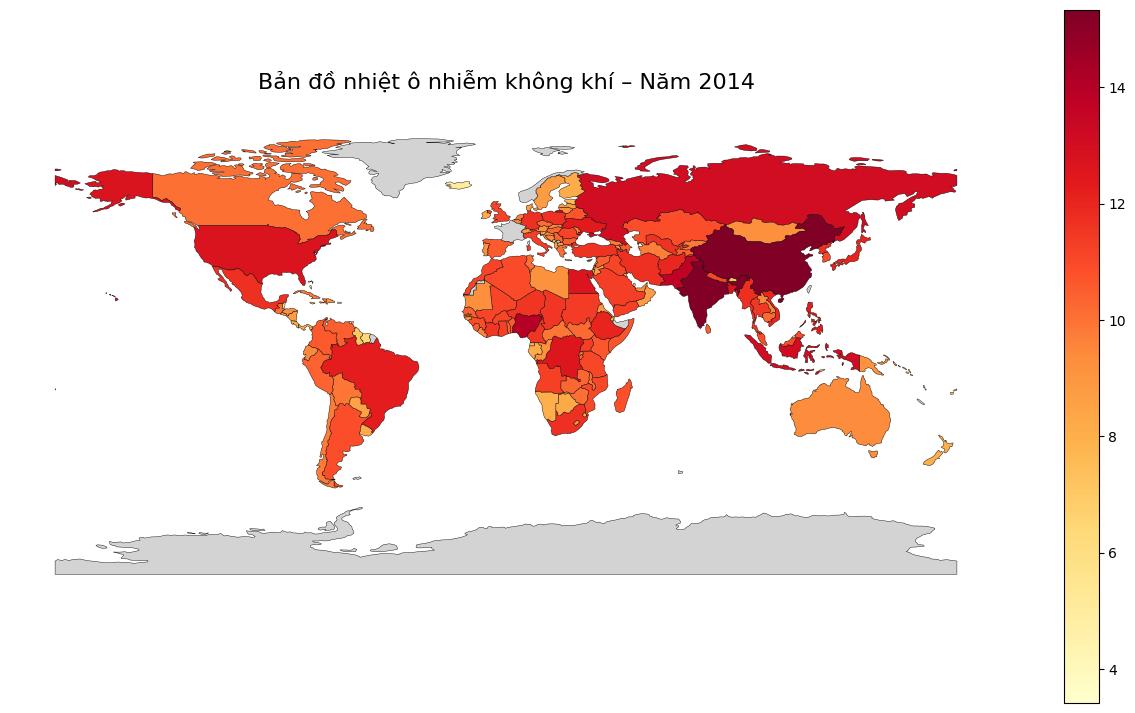

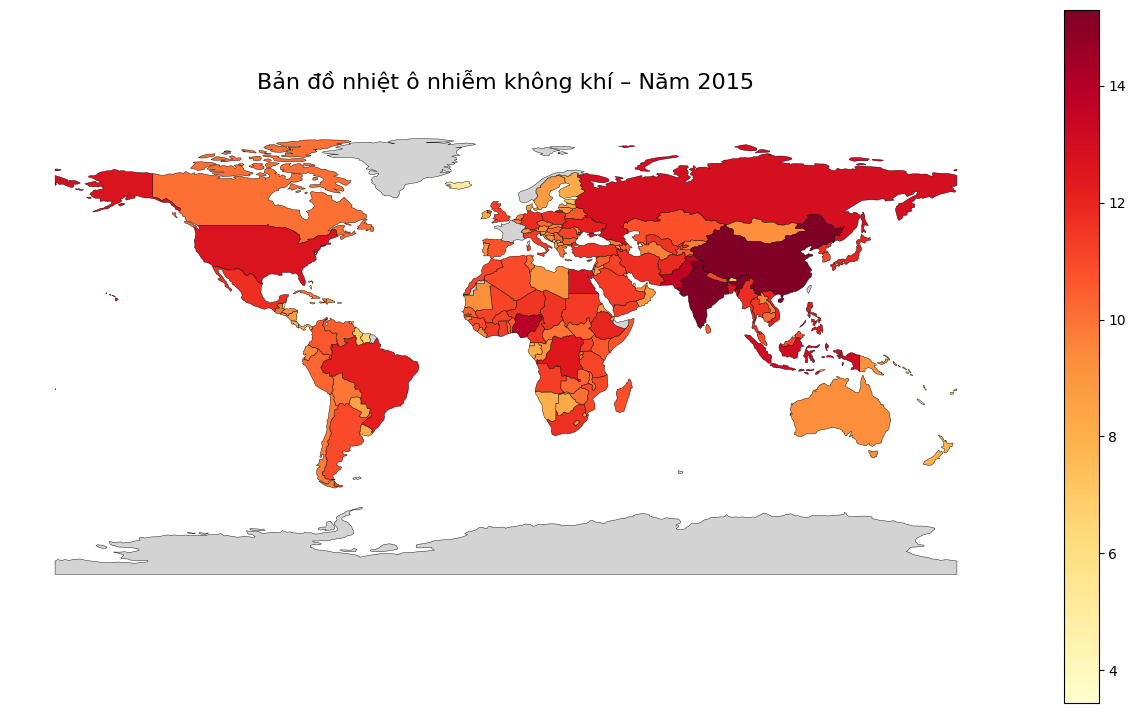

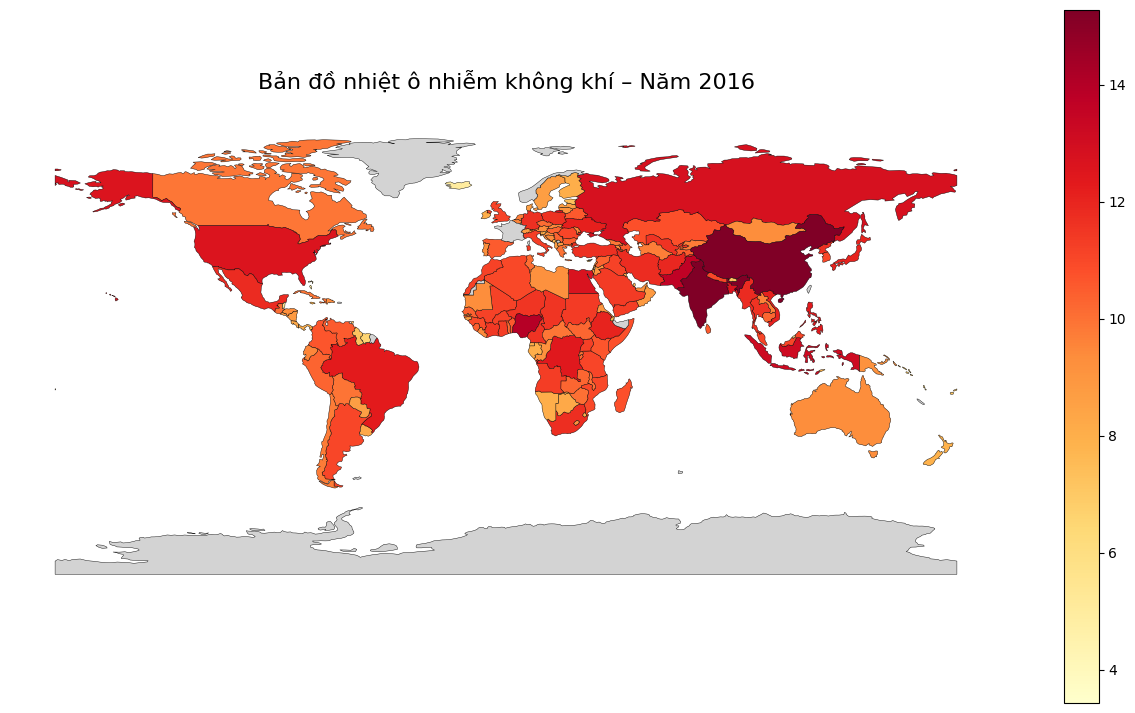

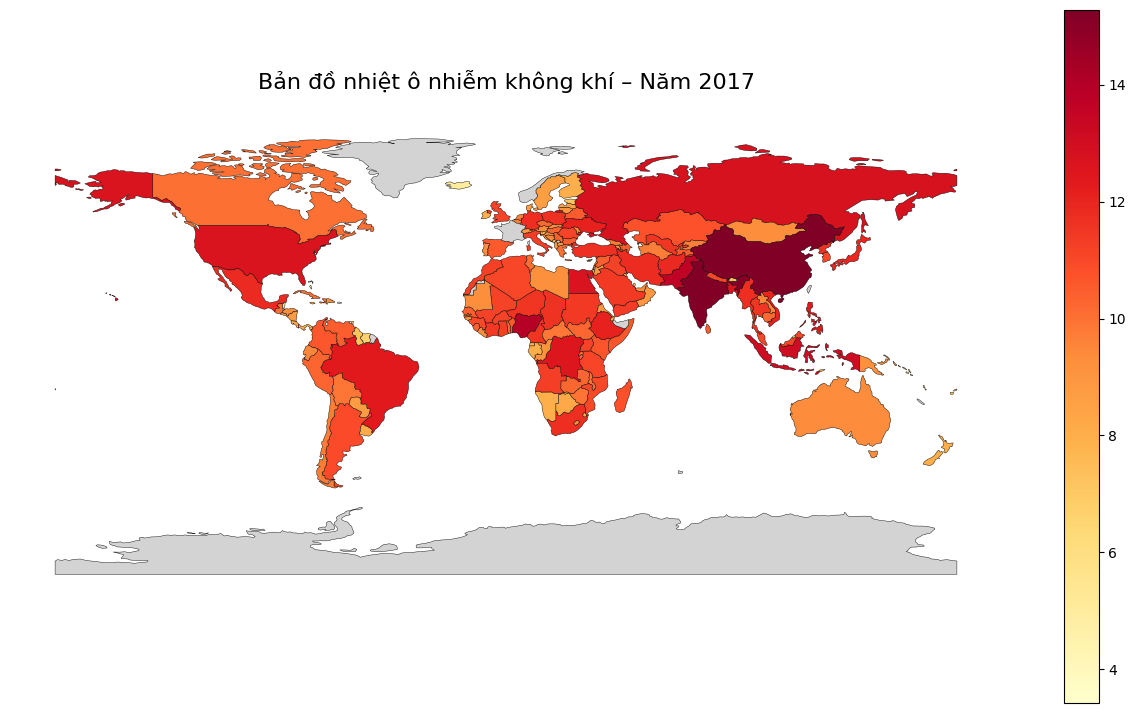

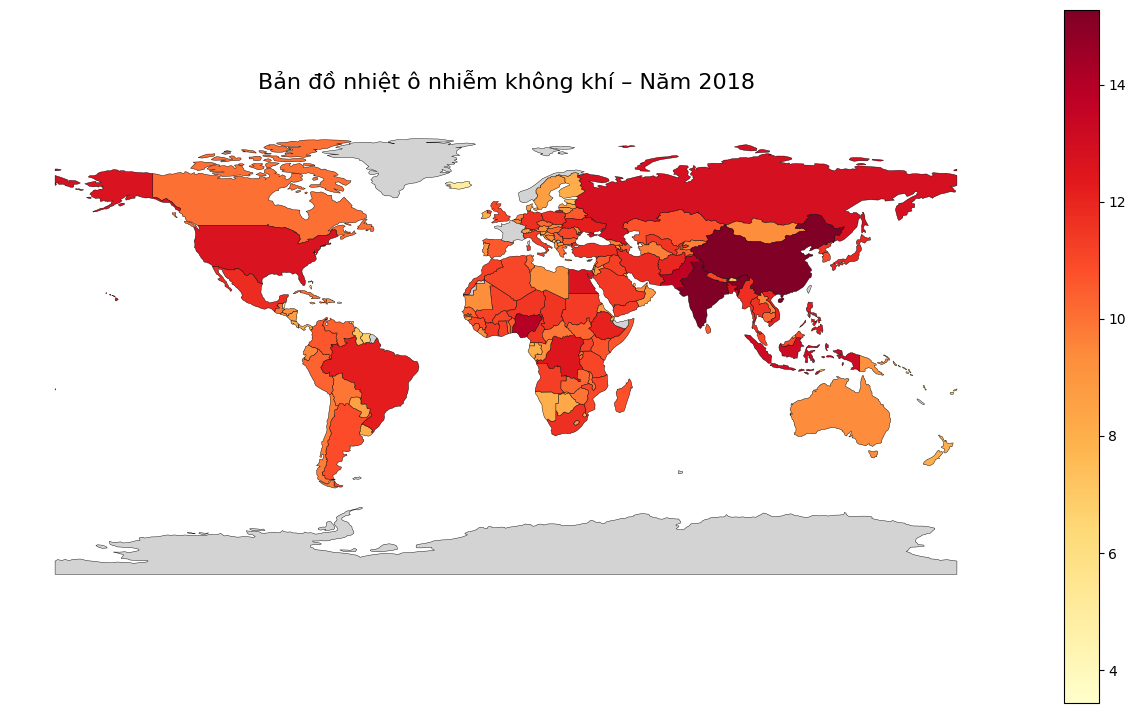

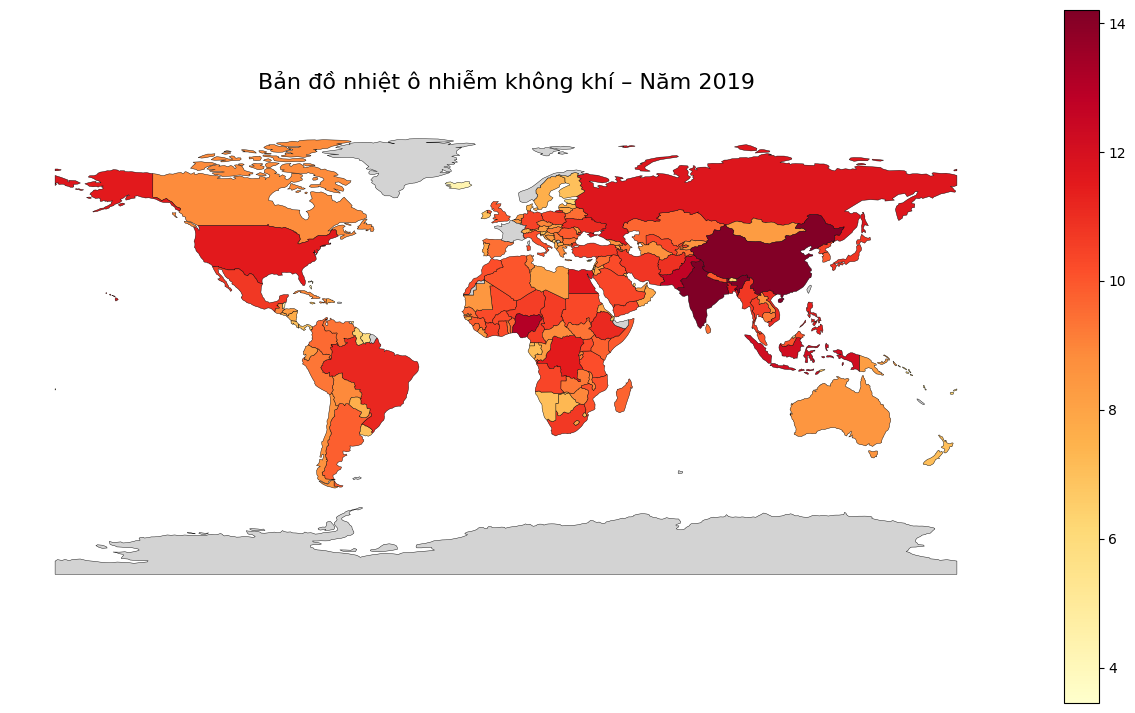

In [22]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np  

df["NumericValue"] = pd.to_numeric(df["NumericValue"], errors="coerce")

df_grouped = (
    df.groupby(
        ["SpatialDim", "ParentLocationCode", "TimeDim"],
        as_index=False
    )
    .agg(
        MeanValue=("NumericValue", "mean"),
        Count=("NumericValue", "count")
    )
)

df_grouped["LogMeanValue"] = np.log1p(df_grouped["MeanValue"])

world = gpd.read_file("../../worldmap/ne_110m_admin_0_countries.shp")

for year in sorted(df_grouped["TimeDim"].unique()):
    df_year = df_grouped[df_grouped["TimeDim"] == year]

    gdf = world.merge(
        df_year,
        how="left",
        left_on="ISO_A3",
        right_on="SpatialDim"
    )

    fig, ax = plt.subplots(figsize=(16, 9))

    gdf.plot(
        column="LogMeanValue",
        ax=ax,
        legend=True,
        cmap="YlOrRd",
        edgecolor="black",
        linewidth=0.3,
        missing_kwds={
            "color": "lightgrey",
            "label": "No data"
        }
    )

    ax.set_title(
        f"Bản đồ nhiệt ô nhiễm không khí – Năm {year}",
        fontsize=16,
        pad=20
    )

    ax.axis("off")
    plt.show()


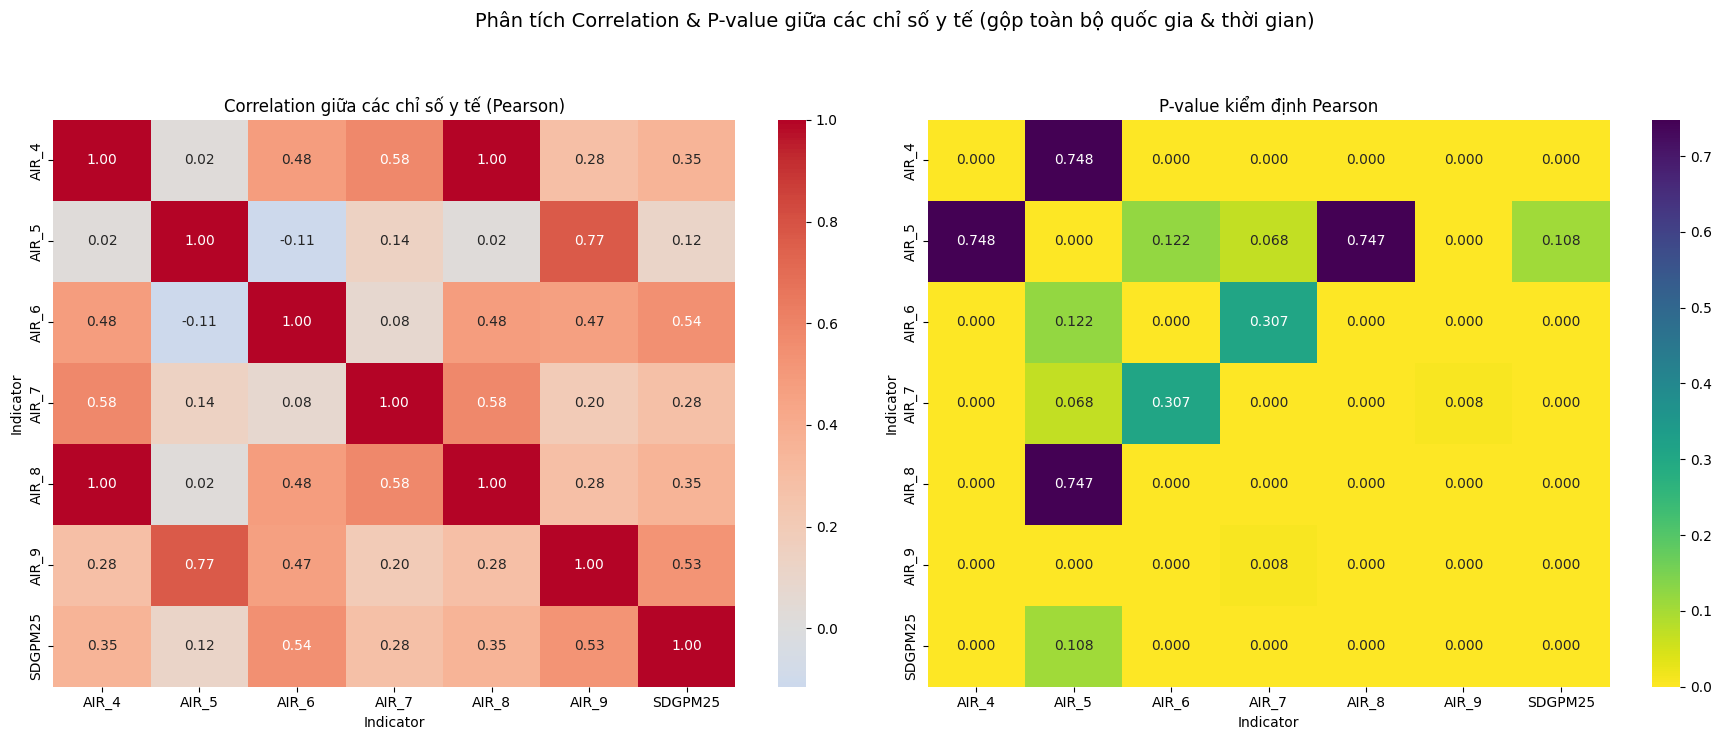

In [23]:
#-------------------------------Corr giữa các chỉ số y tế---------------------------------------
#-----------------------------------------------------------------------------------------------

df_corr = df[["SpatialDim", "TimeDim", "IndicatorCode", "NumericValue"]].copy() 
df_corr["NumericValue"] = pd.to_numeric(df_corr["NumericValue"], errors="coerce") 
pivot = df_corr.pivot_table( index=["SpatialDim", "TimeDim"], columns="IndicatorCode", values="NumericValue", aggfunc="mean" ) 
corr_matrix = pivot.corr(method="pearson")

pval_matrix = pd.DataFrame( np.nan, index=corr_matrix.index, columns=corr_matrix.columns )

for i in corr_matrix.columns: 
    for j in corr_matrix.columns: 
        x = pivot[i] 
        y = pivot[j] 

        valid = pd.concat([x, y], axis=1).dropna() 
        if valid.shape[0] > 2: 
            r, p = pearsonr(valid.iloc[:, 0].values, 
                            valid.iloc[:, 1].values) 
            pval_matrix.loc[i, j] = float(p)


fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ----- Heatmap CORRELATION -----
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    ax=axes[0]
)
axes[0].set_title("Correlation giữa các chỉ số y tế (Pearson)")
axes[0].set_xlabel("Indicator")
axes[0].set_ylabel("Indicator")

# ----- Heatmap P-VALUE -----
sns.heatmap(
    pval_matrix,
    annot=True,
    cmap="viridis_r",
    fmt=".3f",
    ax=axes[1]
)
axes[1].set_title("P-value kiểm định Pearson")
axes[1].set_xlabel("Indicator")
axes[1].set_ylabel("Indicator")

plt.suptitle(
    "Phân tích Correlation & P-value giữa các chỉ số y tế (gộp toàn bộ quốc gia & thời gian)",
    fontsize=14,
    y=1.05
)

plt.tight_layout()
plt.show()


In [ ]:
#-------------------------------Corr theo thời gian --------------------------------------------
#-----------------------------------------------------------------------------------------------

df_corr = df[[
    "SpatialDim",
    "TimeDim",
    "IndicatorCode",
    "NumericValue"
]].copy()

df_corr["NumericValue"] = pd.to_numeric(
    df_corr["NumericValue"], errors="coerce"
)

years = sorted(df_corr["TimeDim"].dropna().unique())

for year in years:
    df_year = df_corr[df_corr["TimeDim"] == year]

    pivot_year = df_year.pivot_table(
        index="SpatialDim",
        columns="IndicatorCode",
        values="NumericValue",
        aggfunc="mean"
    )

    pivot_year = pivot_year.apply(pd.to_numeric, errors="coerce")

    # Không đủ quốc gia để tính corr
    if pivot_year.shape[0] < 3:
        continue

    # ===== CORRELATION =====
    corr_matrix = pivot_year.corr(method="pearson")

    # ===== P-VALUE =====
    indicators = pivot_year.columns
    pval_matrix = pd.DataFrame(
        np.nan,
        index=indicators,
        columns=indicators
    )

    for i in indicators:
        for j in indicators:
            if i == j:
                pval_matrix.loc[i, j] = 0.0
            else:
                valid = pivot_year[[i, j]].dropna()

                if valid.shape[0] > 2:
                    _, p = pearsonr(
                        valid[i].values,
                        valid[j].values
                    )
                    pval_matrix.loc[i, j] = float(p)

    # ===== VẼ COMBINED FIGURE =====
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # --- Corr ---
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        center=0,
        fmt=".2f",
        ax=axes[0]
    )
    axes[0].set_title(f"Correlation (Pearson) – Năm {year}")
    axes[0].set_xlabel("Indicator")
    axes[0].set_ylabel("Indicator")

    # --- P-value ---
    sns.heatmap(
        pval_matrix,
        annot=True,
        cmap="viridis_r",
        fmt=".3f",
        ax=axes[1]
    )
    axes[1].set_title(f"P-value (Pearson) – Năm {year}")
    axes[1].set_xlabel("Indicator")
    axes[1].set_ylabel("Indicator")

    plt.suptitle(
        f"Phân tích Correlation & P-value giữa các chỉ số y tế – Năm {year}",
        fontsize=14,
        y=1.05
    )

    plt.tight_layout()
    plt.show()

In [ ]:
#-------------------------------Corr theo quốc gia---------------------------------------
#-----------------------------------------------------------------------------------------

df_corr = df[[
    "SpatialDim",
    "TimeDim",
    "IndicatorCode",
    "NumericValue"
]].copy()

df_corr["NumericValue"] = pd.to_numeric(
    df_corr["NumericValue"], errors="coerce"
)

countries = sorted(df_corr["SpatialDim"].dropna().unique())

for country in countries:
    df_country = df_corr[df_corr["SpatialDim"] == country]

    pivot_country = df_country.pivot_table(
        index="TimeDim",
        columns="IndicatorCode",
        values="NumericValue",
        aggfunc="mean"
    )

    # Ép kiểu số
    pivot_country = pivot_country.apply(pd.to_numeric, errors="coerce")

    # Cần đủ dữ liệu theo thời gian
    if pivot_country.shape[0] < 3:
        continue

    # ===== CORRELATION =====
    corr_matrix = pivot_country.corr(method="pearson")

    # ===== P-VALUE =====
    indicators = pivot_country.columns
    pval_matrix = pd.DataFrame(
        np.nan,
        index=indicators,
        columns=indicators
    )

    for i in indicators:
        for j in indicators:
            if i == j:
                pval_matrix.loc[i, j] = 0.0
            else:
                valid = pivot_country[[i, j]].dropna()

                if valid.shape[0] > 2:
                    _, p = pearsonr(
                        valid[i].values,
                        valid[j].values
                    )
                    pval_matrix.loc[i, j] = float(p)

    # ===== VẼ HEATMAP =====
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        center=0,
        fmt=".2f",
        ax=axes[0]
    )
    axes[0].set_title(f"Correlation – {country}")

    sns.heatmap(
        pval_matrix,
        annot=True,
        cmap="viridis_r",
        fmt=".3f",
        ax=axes[1]
    )
    axes[1].set_title(f"P-value – {country}")

    plt.suptitle(
        f"Phân tích Corr & P-value theo thời gian – Quốc gia {country}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()
